## Introduction 

In this script, the straightness per ward is computed. First, the straightness for the entire Bangalore is computed and then a loop is created where the straightness for each ward is obtained. 

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [6]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml_drive.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [7]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [8]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [9]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 369 wards in the dataset.


Reading in the entire Bangalore network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [10]:
G = ox.io.load_graphml(path_graphml)

In [11]:
G.graph["crs"]

'epsg:4326'

In [12]:
df.crs.to_epsg()

4326

## Computing street straightness at the ward level

In [16]:
results = pd.DataFrame(columns=['ward_id', 'ward_name', 'Corporatio', 'straightness'])
results

,ward_id,ward_name,Corporatio,straightness


In [17]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    id_ward = df['ward_id'].iloc[ward]
    name_ward = df['ward_name'].iloc[ward]
    corporation = df['Corporatio'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.straightness_centrality(primal)

    nodes = momepy.nx_to_gdf(primal, lines=False)


    straightness_mean = nodes['straightness'].mean()

    ## print(straightness_mean)

    results.loc[ward] = [
        id_ward,
        name_ward,
        corporation,
        straightness_mean
    ]
    

Processing wards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 369/369 [48:26<00:00,  7.88s/it]


In [18]:
results

,ward_id,ward_name,Corporatio,straightness
0,25,25 - Vinayaka Layout,West,0.736976
1,2,2 - Aerocity,North,0.693418
2,3,3 - Chowdeshwari ward,North,0.685726
3,15,15 - Ramamurthy Nagara,East,0.696362
4,58,58 - Nagashettyhalli,North,0.695818
...,...,...,...,...
364,56,56 - Gopalpura,Central,0.688229
365,57,57 - Cottonpete,Central,0.762392
366,54,54 - Binnypete,Central,0.590193
367,47,47 - IPD Salappa Ward,Central,0.710204


In [19]:
top10_highest = (
    results
    .sort_values(by='straightness', ascending=False)
    .head(10)
)
top10_highest

,ward_id,ward_name,Corporatio,straightness
190,102,102 - Hanumanthanagar,West,0.811961
21,41,41 - V.V Puram,Central,0.800038
159,65,65 - Manjunath Nagara,West,0.799961
287,42,42 - Sunkenahalli,Central,0.799225
171,71,71 - Thimmenahalli,West,0.796931
294,44,44 - Chamarajpet,Central,0.796758
339,53,53 - Malleshwaram,West,0.796601
328,103,103 - N.R Colony,West,0.796549
302,55,55 - Subramanyanagara,West,0.794798
126,27,27 - Ambedkarnagar,Central,0.792503


In [20]:
top10_lowest = (
    results
    .sort_values(by='straightness', ascending=True)
    .head(10)
)
top10_lowest

,ward_id,ward_name,Corporatio,straightness
348,94,94 - Deepanjali Nagara,West,0.544954
138,15,15 - Byatarayanapura,North,0.556643
130,31,31 - Kasavanahalli,South,0.566527
200,8,8 - Anandapura,East,0.581905
73,38,38 - Doddakammanahalli,South,0.584232
224,31,31 - Kadugodi,East,0.589222
366,54,54 - Binnypete,Central,0.590193
147,64,64 - Hongasandra,South,0.594263
113,61,61 - HMT Ward,North,0.594388
197,5,5 - Hoysala Nagara East,East,0.595142


In [21]:
print(f'The mean of the straigthness across the wards is {results["straightness"].mean()}.')
print(f'The minimum of the straigthness across the wards is {results["straightness"].min()}.')
print(f'The maximum of the straigthness across the wards is {results["straightness"].max()}.')

The mean of the straigthness across the wards is 0.698982792980947.
The minimum of the straigthness across the wards is 0.544953808252168.
The maximum of the straigthness across the wards is 0.8119606157625158.


In [22]:
## Save this:
results_path = PROCESSED_DIR / "results_bangalore_straightness_all_roads_drive.csv"

results.to_csv(results_path)

In [72]:
# You can normally do things from results but I had to read them in later
results_path = PROCESSED_DIR / "results_bangalore_straightness_all_roads_drive.csv"
results = pd.read_csv(results_path)

In [23]:
results = pd.read_csv(results_path)
results

,Unnamed: 0,ward_id,ward_name,Corporatio,straightness
0,0,25,25 - Vinayaka Layout,West,0.736976
1,1,2,2 - Aerocity,North,0.693418
2,2,3,3 - Chowdeshwari ward,North,0.685726
3,3,15,15 - Ramamurthy Nagara,East,0.696362
4,4,58,58 - Nagashettyhalli,North,0.695818
...,...,...,...,...,...
364,364,56,56 - Gopalpura,Central,0.688229
365,365,57,57 - Cottonpete,Central,0.762392
366,366,54,54 - Binnypete,Central,0.590193
367,367,47,47 - IPD Salappa Ward,Central,0.710204


In [24]:
df_merged = df.merge(results, on = 'ward_name')
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,Unnamed: 0,ward_id_y,Corporatio_y,straightness
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0,25,West,0.736976
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",1,2,North,0.693418
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",2,3,North,0.685726
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",3,15,East,0.696362
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",4,58,North,0.695818
...,...,...,...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",364,56,Central,0.688229
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",365,57,Central,0.762392
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",366,54,Central,0.590193
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",367,47,Central,0.710204


In [25]:
df_merged = df_merged[['ward_id_x', 'ward_name', 'Corporatio_x', 'geometry', 'straightness']]
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,straightness
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0.736976
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",0.693418
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",0.685726
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",0.696362
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",0.695818
...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",0.688229
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",0.762392
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",0.590193
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",0.710204


In [26]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio_x': 'Corporatio'
})

## Plots

The ward with the highest straightness

In [27]:
# Find the index label of the row with the maximum value in column 'C'
mask = df_merged['straightness'] == df_merged['straightness'].max()

# Apply the mask to the DataFrame
max_rows_df = df_merged[mask]

print(max_rows_df)

    ward_id              ward_name Corporatio  \
190     102  102 - Hanumanthanagar       West   

                                              geometry  straightness  
190  POLYGON ((77.55241 12.94198, 77.55253 12.94348...      0.811961  


In [28]:
print(f'The ward with the highest straightness is {max_rows_df["ward_name"]}')


The ward with the highest straightness is 190    102 - Hanumanthanagar
Name: ward_name, dtype: object


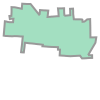

In [29]:
geom_highest = max_rows_df.geometry.iloc[0]
geom_highest

In [30]:
# Extract the network with the highest ward:
G_highest = ox.graph_from_polygon(
    geom_highest,
    simplify=True)

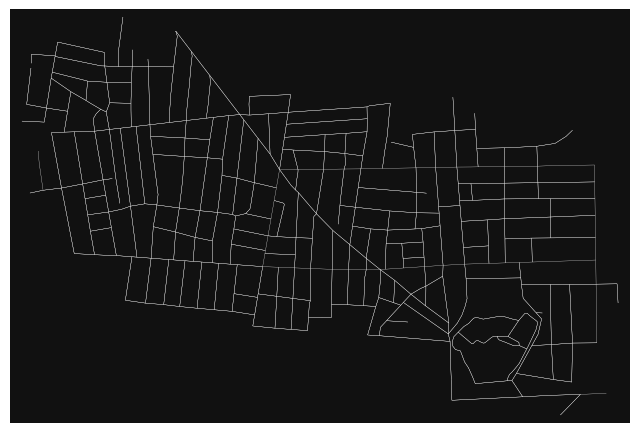

In [31]:
fig, ax = ox.plot_graph(G_highest, node_size=0, edge_color="w", edge_linewidth=0.2)

In [32]:
# Find the index label of the row with the maximum value in column 'C'
mask = df_merged['straightness'] == df_merged['straightness'].min()

# Apply the mask to the DataFrame
min_rows_df = df_merged[mask]

print(min_rows_df)

    ward_id               ward_name Corporatio  \
348      94  94 - Deepanjali Nagara       West   

                                              geometry  straightness  
348  POLYGON ((77.5343 12.93647, 77.5343 12.93647, ...      0.544954  


In [33]:
print(f'The ward with the lowest straightness is {min_rows_df["ward_name"]}')

The ward with the lowest straightness is 348    94 - Deepanjali Nagara
Name: ward_name, dtype: object


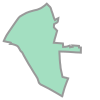

In [34]:
geom_lowest = min_rows_df.geometry.iloc[0]
geom_lowest

In [35]:
# Extract the network with the highest ward:
G_lowest = ox.graph_from_polygon(
    geom_lowest,
    simplify=True)

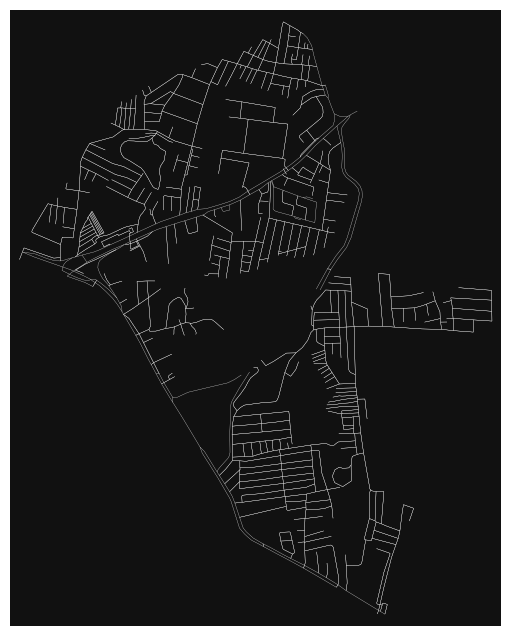

In [36]:
fig, ax = ox.plot_graph(G_lowest, node_size=0, edge_color="w", edge_linewidth=0.2)

In [37]:
G_clipped_lowest = ox.truncate.truncate_graph_polygon(G, geom_lowest)

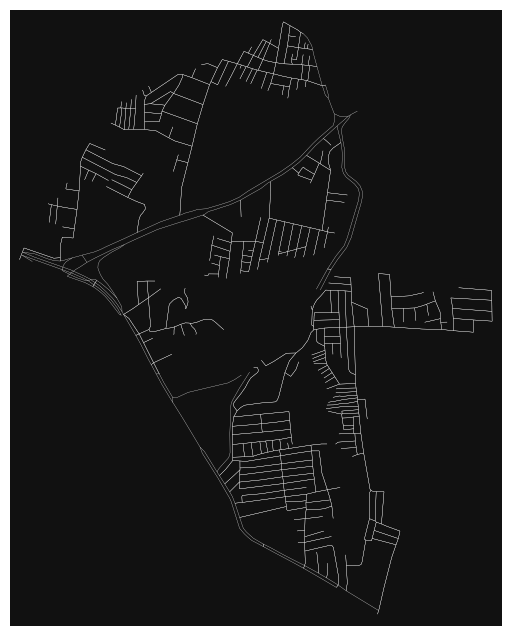

In [38]:
fig, ax = ox.plot_graph(G_clipped_lowest, node_size=0, edge_color="w", edge_linewidth=0.2)

Plot the straightness at the wards:

In [39]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'straightness_all_roads_bangalore_drive.png'

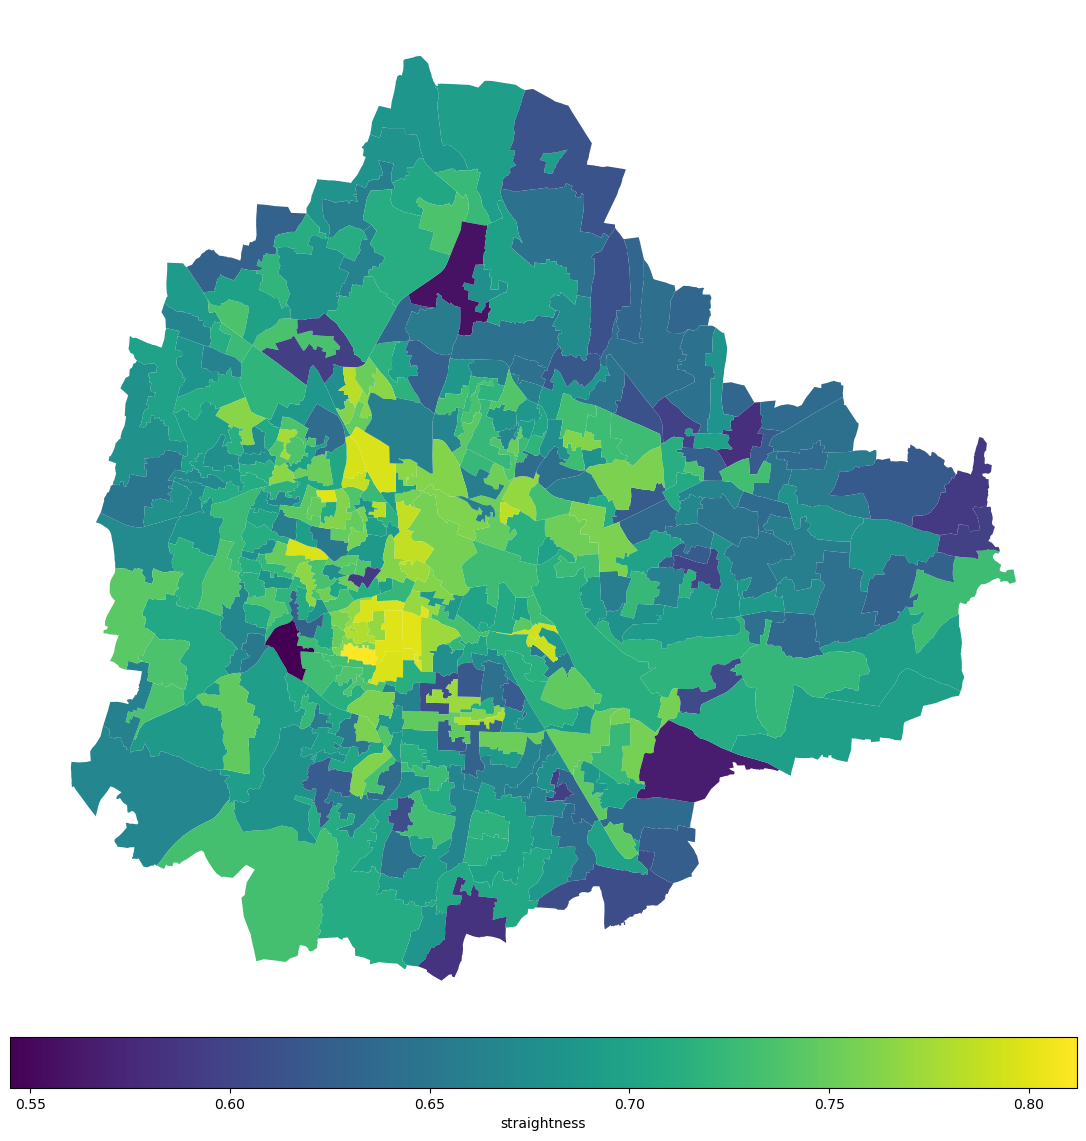

In [40]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="straightness",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "straightness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()